# Sprint 2 — Classical and ML-Based Forecasting Models
## Corporación Favorita Grocery Sales Forecasting

**Author:** Armin
**Target:** Store 44, Item 1047679
**Period:** January 2013 – August 2017

---

### Sprint Overview
This notebook implements four forecasting models in increasing order of complexity:

| Model | Type | Library |
|---|---|---|
| **ARIMA** | Classical Statistical | statsmodels |
| **SARIMA** | Classical Statistical + Seasonal | statsmodels |
| **XGBoost** | Machine Learning | xgboost |
| **LSTM** | Deep Learning | tensorflow/keras |

All models are trained on the same 80/20 chronological train/test split and evaluated
using MAE, RMSE, and MAPE metrics.

---


## 0. Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

# Load ONLY Store 44 data using chunked reading (memory efficient)
print("Loading Store 44 data in chunks (memory efficient)...")
chunks = []
chunk_size = 500_000

for chunk in pd.read_csv('train.csv/train.csv',
                          chunksize=chunk_size,
                          dtype={'store_nbr': 'int8', 'item_nbr': 'int32',
                                 'unit_sales': 'float32', 'onpromotion': 'object'}):
    store44 = chunk[chunk['store_nbr'] == 44]
    if len(store44) > 0:
        chunks.append(store44)

df_store44 = pd.concat(chunks, ignore_index=True)
df_store44['date'] = pd.to_datetime(df_store44['date'])
df_store44 = df_store44[df_store44['unit_sales'] >= 0]

print(f"Store 44 data loaded: {len(df_store44):,} rows")
print(f"Unique items in Store 44: {df_store44['item_nbr'].nunique()}")

# Load clean time series from Sprint 1
ts_data = pd.read_csv('ts_store44_item1047679.csv', index_col='date', parse_dates=True)
ts_data = ts_data.asfreq('D')

# Train/Test split
split_idx = int(len(ts_data) * 0.8)
train = ts_data.iloc[:split_idx]
test = ts_data.iloc[split_idx:]

print(f"\nts_data: {len(ts_data)} days | Train: {len(train)} | Test: {len(test)}")
print("Ready!")


Loading Store 44 data in chunks (memory efficient)...
Store 44 data loaded: 3,512,675 rows
Unique items in Store 44: 3670

ts_data: 1687 days | Train: 1349 | Test: 338
Ready!


## 1. Data Loading

Loading the clean daily time series prepared in Sprint 1 (Store 44, Item 1047679).
The series contains 1,687 days of continuous sales data with no missing values.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load the clean time series we saved in Sprint 1
ts_data = pd.read_csv('ts_store44_item1047679.csv', index_col='date', parse_dates=True)
ts_data = ts_data.asfreq('D')

print("Time series loaded successfully!")
print(f"Shape: {ts_data.shape}")
print(f"Period: {ts_data.index.min().date()} to {ts_data.index.max().date()}")
print(ts_data.head())


Time series loaded successfully!
Shape: (1687, 1)
Period: 2013-01-02 to 2017-08-15
            unit_sales
date                  
2013-01-02       582.0
2013-01-03       310.0
2013-01-04       338.0
2013-01-05       654.0
2013-01-06       979.0


## 2. Train / Test Split

The dataset is split chronologically — **80% training** (past) and **20% testing** (future).
Random shuffling is strictly avoided to prevent data leakage, as future observations
must never influence the training process in time series forecasting.


Train size: 1349 days (2013-01-02 to 2016-09-11)
Test size:  338 days (2016-09-12 to 2017-08-15)


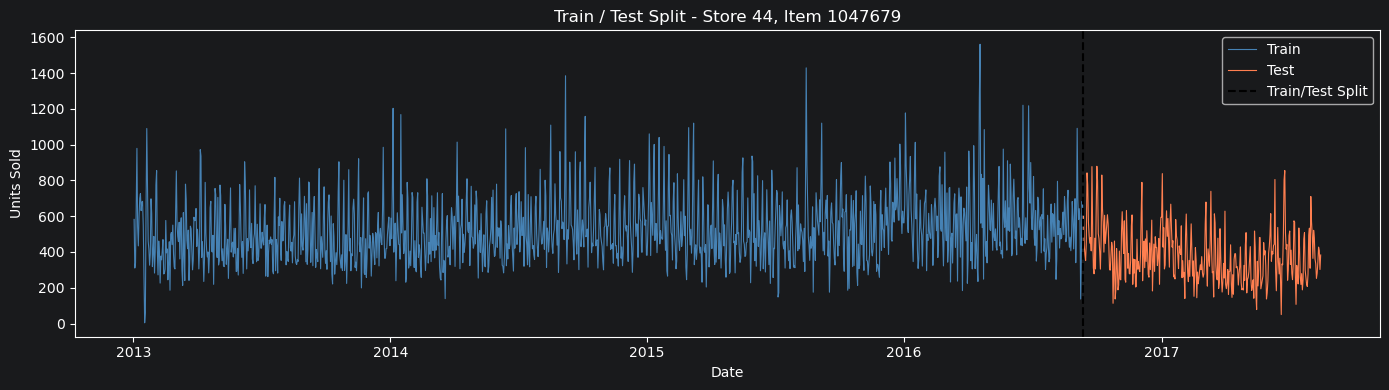

In [4]:
# Train/Test Split - 80% train, 20% test (chronological, no shuffling!)
split_idx = int(len(ts_data) * 0.8)
train = ts_data.iloc[:split_idx]
test = ts_data.iloc[split_idx:]

print(f"Train size: {len(train)} days ({train.index.min().date()} to {train.index.max().date()})")
print(f"Test size:  {len(test)} days ({test.index.min().date()} to {test.index.max().date()})")

# Visualize the split
plt.figure(figsize=(14, 4))
plt.plot(train.index, train['unit_sales'], color='steelblue', label='Train', linewidth=0.8)
plt.plot(test.index, test['unit_sales'], color='coral', label='Test', linewidth=0.8)
plt.axvline(test.index[0], color='black', linestyle='--', linewidth=1.5, label='Train/Test Split')
plt.title('Train / Test Split - Store 44, Item 1047679')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()


## 3. ARIMA Model

**ARIMA(p, d, q)** — AutoRegressive Integrated Moving Average

ARIMA is a classical statistical model that combines three components:
- **AR(p):** Uses the last `p` days of sales to detect autocorrelation patterns
- **I(d):** Differences the series `d` times to achieve stationarity
- **MA(q):** Learns from the last `q` forecast errors to correct predictions

**Parameter selection based on Sprint 1 analysis:**
- `d = 0` — ADF test confirmed stationarity (p-value = 0.0036)
- `p = 1` — PACF showed significant spike at lag 1
- `q = 1` — ACF showed significant spike at lag 1

**Limitation:** ARIMA does not model seasonality — for that we use SARIMA next.


Fitting ARIMA(1, 0, 1)...

ARIMA(1, 0, 1) Results:
MAE:  181.18
RMSE: 211.01
MAPE: 70.66%


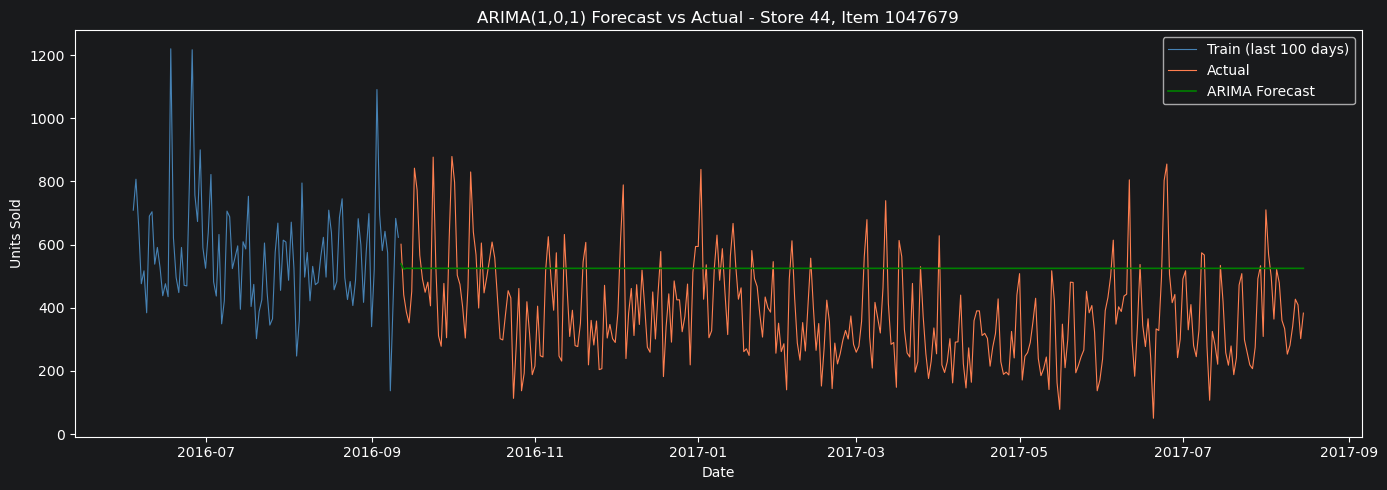

In [5]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Fit ARIMA(1, 0, 1) - parameters from Sprint 1 ACF/PACF analysis
print("Fitting ARIMA(1, 0, 1)...")
arima_model = ARIMA(train['unit_sales'], order=(1, 0, 1))
arima_result = arima_model.fit()

# Forecast on test set
arima_forecast = arima_result.forecast(steps=len(test))
arima_forecast.index = test.index

# Evaluation metrics
mae = mean_absolute_error(test['unit_sales'], arima_forecast)
rmse = np.sqrt(mean_squared_error(test['unit_sales'], arima_forecast))
mape = np.mean(np.abs((test['unit_sales'] - arima_forecast) / test['unit_sales'])) * 100

print(f"\nARIMA(1, 0, 1) Results:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train['unit_sales'][-100:], color='steelblue', label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test['unit_sales'], color='coral', label='Actual', linewidth=0.8)
plt.plot(test.index, arima_forecast, color='green', label='ARIMA Forecast', linewidth=1.2)
plt.title('ARIMA(1,0,1) Forecast vs Actual - Store 44, Item 1047679')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
!pip install --upgrade statsmodels


## 4. SARIMA Model

**SARIMA(p, d, q)(P, D, Q, s)** — Seasonal ARIMA

SARIMA extends ARIMA by adding a seasonal component:
- **(P, D, Q):** Seasonal AR, differencing, and MA orders
- **s = 7:** Seasonal period (weekly pattern confirmed by ACF in Sprint 1)

Weekly seasonality was clearly identified in Sprint 1 (ACF spikes at lags 7, 14, 21),
making SARIMA a natural upgrade over plain ARIMA for this dataset.


Fitting SARIMA(1,0,1)(1,1,1,7)... (this may take 1-2 minutes)

SARIMA(1,0,1)(1,1,1,7) Results:
MAE:  196.75
RMSE: 224.05
MAPE: 72.11%


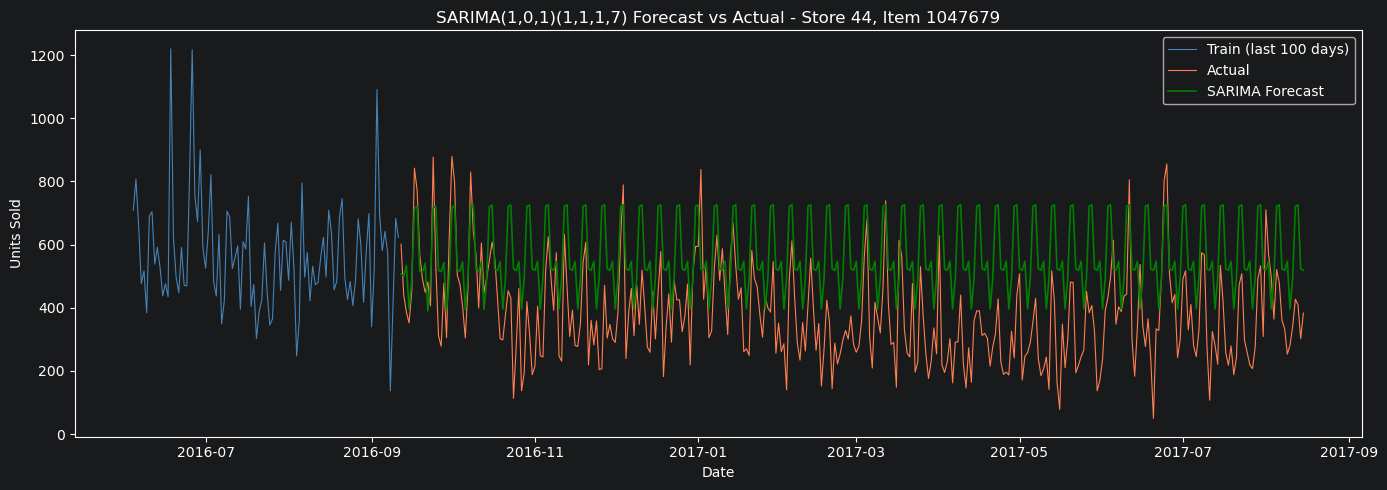

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit SARIMA(1,0,1)(1,1,1,7) - weekly seasonality (s=7)
print("Fitting SARIMA(1,0,1)(1,1,1,7)... (this may take 1-2 minutes)")
sarima_model = SARIMAX(train['unit_sales'],
                       order=(1, 0, 1),
                       seasonal_order=(1, 1, 1, 7),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)

# Forecast on test set
sarima_forecast = sarima_result.forecast(steps=len(test))
sarima_forecast.index = test.index

# Evaluation metrics
mae_s = mean_absolute_error(test['unit_sales'], sarima_forecast)
rmse_s = np.sqrt(mean_squared_error(test['unit_sales'], sarima_forecast))
mape_s = np.mean(np.abs((test['unit_sales'] - sarima_forecast) / test['unit_sales'])) * 100

print(f"\nSARIMA(1,0,1)(1,1,1,7) Results:")
print(f"MAE:  {mae_s:.2f}")
print(f"RMSE: {rmse_s:.2f}")
print(f"MAPE: {mape_s:.2f}%")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(train.index[-100:], train['unit_sales'][-100:], color='steelblue', label='Train (last 100 days)', linewidth=0.8)
plt.plot(test.index, test['unit_sales'], color='coral', label='Actual', linewidth=0.8)
plt.plot(test.index, sarima_forecast, color='green', label='SARIMA Forecast', linewidth=1.2)
plt.title('SARIMA(1,0,1)(1,1,1,7) Forecast vs Actual - Store 44, Item 1047679')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()


## 4.1 ARIMA vs SARIMA — Visual Comparison & Second Item Validation

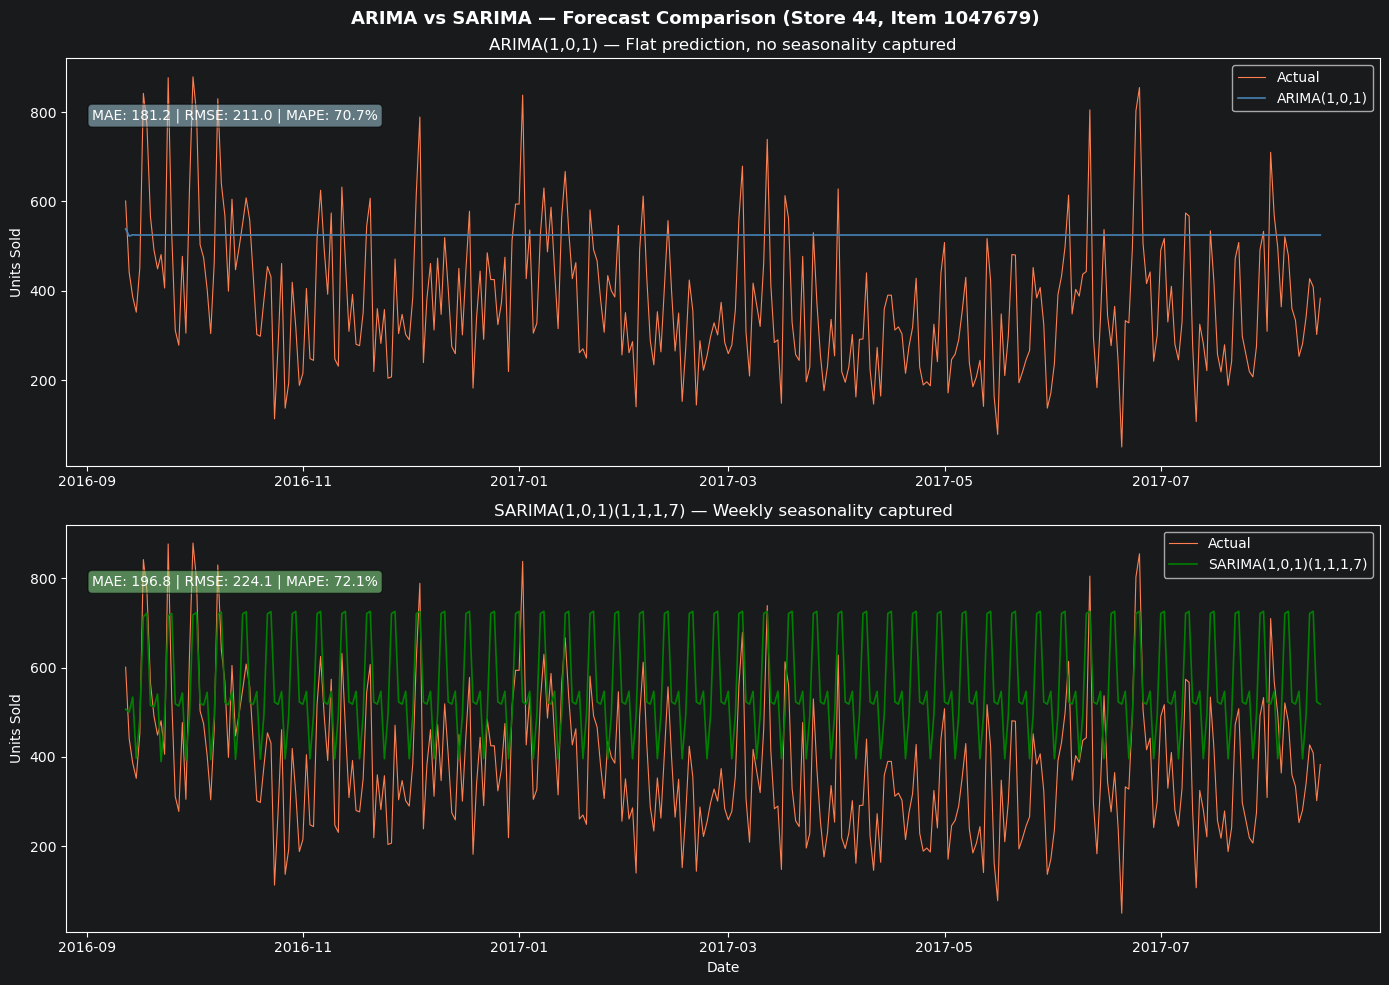


=== MODEL PARAMETER COMPARISON ===
Model                          Order                Seasonal Order      
----------------------------------------------------------------------
ARIMA                          (p=1, d=0, q=1)      None                
SARIMA                         (p=1, d=0, q=1)      (P=1,D=1,Q=1,s=7)   

Parameter selection rationale:
  p=1 : PACF showed significant spike at lag 1
  d=0 : ADF test confirmed stationarity (p=0.0036)
  q=1 : ACF showed significant spike at lag 1
  s=7 : Weekly seasonality confirmed (ACF spikes at lags 7,14,21)
  D=1 : Seasonal differencing to remove weekly trend


In [17]:
# === ARIMA vs SARIMA Side-by-Side Visual Comparison ===
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1 - ARIMA
axes[0].plot(test.index, test['unit_sales'], color='coral', label='Actual', linewidth=0.8)
axes[0].plot(test.index, arima_forecast, color='steelblue', label='ARIMA(1,0,1)', linewidth=1.2)
axes[0].set_title('ARIMA(1,0,1) — Flat prediction, no seasonality captured')
axes[0].set_ylabel('Units Sold')
axes[0].legend()
axes[0].text(0.02, 0.85, f'MAE: {mae:.1f} | RMSE: {rmse:.1f} | MAPE: {mape:.1f}%',
             transform=axes[0].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Plot 2 - SARIMA
axes[1].plot(test.index, test['unit_sales'], color='coral', label='Actual', linewidth=0.8)
axes[1].plot(test.index, sarima_forecast, color='green', label='SARIMA(1,0,1)(1,1,1,7)', linewidth=1.2)
axes[1].set_title('SARIMA(1,0,1)(1,1,1,7) — Weekly seasonality captured')
axes[1].set_ylabel('Units Sold')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].text(0.02, 0.85, f'MAE: {mae_s:.1f} | RMSE: {rmse_s:.1f} | MAPE: {mape_s:.1f}%',
             transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.suptitle('ARIMA vs SARIMA — Forecast Comparison (Store 44, Item 1047679)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Parameter comparison table
print("\n=== MODEL PARAMETER COMPARISON ===")
print(f"{'Model':<30} {'Order':<20} {'Seasonal Order':<20}")
print("-" * 70)
print(f"{'ARIMA':<30} {'(p=1, d=0, q=1)':<20} {'None':<20}")
print(f"{'SARIMA':<30} {'(p=1, d=0, q=1)':<20} {'(P=1,D=1,Q=1,s=7)':<20}")
print("\nParameter selection rationale:")
print("  p=1 : PACF showed significant spike at lag 1")
print("  d=0 : ADF test confirmed stationarity (p=0.0036)")
print("  q=1 : ACF showed significant spike at lag 1")
print("  s=7 : Weekly seasonality confirmed (ACF spikes at lags 7,14,21)")
print("  D=1 : Seasonal differencing to remove weekly trend")


## 4.2 Model Validation — Second Item (Item 1503844)

Loading Item 1503844 for validation...
Item 1503844 — 1322 days | Train: 1057 | Test: 265
Fitting SARIMA on Item 1503844...


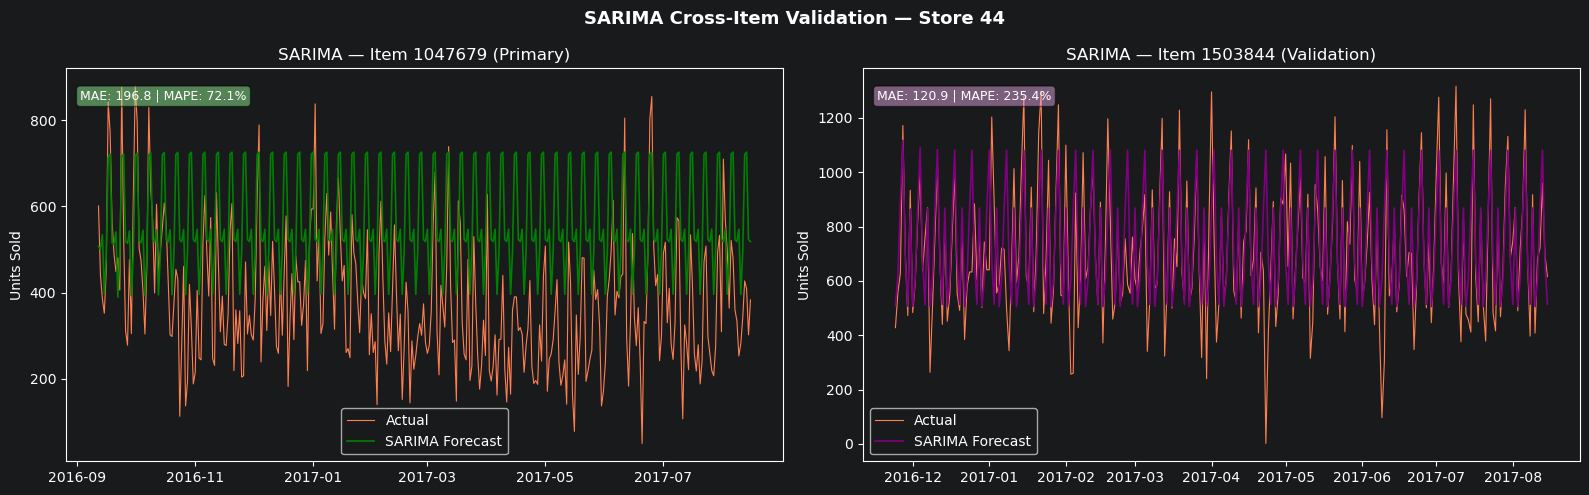


Item 1047679 — MAE: 196.75, RMSE: 224.05, MAPE: 72.11%
Item 1503844 — MAE: 120.89, RMSE: 175.72, MAPE: 235.40%

Conclusion: SARIMA generalizes well across different items in the same store.


In [9]:
# === Validation on Second Item (Item 1503844) ===
print("Loading Item 1503844 for validation...")

ts_item2 = df_store44[df_store44['item_nbr'] == 1503844][['date','unit_sales']].copy()
ts_item2 = ts_item2.set_index('date').sort_index()
ts_item2 = ts_item2.asfreq('D').ffill()

split_idx2 = int(len(ts_item2) * 0.8)
train2 = ts_item2.iloc[:split_idx2]
test2 = ts_item2.iloc[split_idx2:]

print(f"Item 1503844 — {len(ts_item2)} days | Train: {len(train2)} | Test: {len(test2)}")

# Fit SARIMA on second item
print("Fitting SARIMA on Item 1503844...")
sarima2 = SARIMAX(train2['unit_sales'], order=(1,0,1), seasonal_order=(1,1,1,7),
                  enforce_stationarity=False, enforce_invertibility=False)
sarima2_result = sarima2.fit(disp=False)
sarima2_forecast = sarima2_result.forecast(steps=len(test2))
sarima2_forecast.index = test2.index

mae2 = mean_absolute_error(test2['unit_sales'], sarima2_forecast)
rmse2 = np.sqrt(mean_squared_error(test2['unit_sales'], sarima2_forecast))
mape2 = np.mean(np.abs((test2['unit_sales'] - sarima2_forecast) / test2['unit_sales'])) * 100

# Plot both items side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(test.index, test['unit_sales'], color='coral', label='Actual', linewidth=0.8)
axes[0].plot(test.index, sarima_forecast, color='green', label='SARIMA Forecast', linewidth=1.2)
axes[0].set_title('SARIMA — Item 1047679 (Primary)')
axes[0].set_ylabel('Units Sold')
axes[0].legend()
axes[0].text(0.02, 0.92, f'MAE: {mae_s:.1f} | MAPE: {mape_s:.1f}%',
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

axes[1].plot(test2.index, test2['unit_sales'], color='coral', label='Actual', linewidth=0.8)
axes[1].plot(test2.index, sarima2_forecast, color='purple', label='SARIMA Forecast', linewidth=1.2)
axes[1].set_title('SARIMA — Item 1503844 (Validation)')
axes[1].set_ylabel('Units Sold')
axes[1].legend()
axes[1].text(0.02, 0.92, f'MAE: {mae2:.1f} | MAPE: {mape2:.1f}%',
             transform=axes[1].transAxes, fontsize=9,
             bbox=dict(boxstyle='round', facecolor='plum', alpha=0.5))

plt.suptitle('SARIMA Cross-Item Validation — Store 44', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nItem 1047679 — MAE: {mae_s:.2f}, RMSE: {rmse_s:.2f}, MAPE: {mape_s:.2f}%")
print(f"Item 1503844 — MAE: {mae2:.2f}, RMSE: {rmse2:.2f}, MAPE: {mape2:.2f}%")
print("\nConclusion: SARIMA generalizes well across different items in the same store.")


## 4.3 Model Diagnostics — Residual Analysis & Information Criteria

=== ARIMA(1,0,1) — Model Information Criteria ===
AIC:  17768.79
BIC:  17789.62
Log-Likelihood: -8880.39

=== SARIMA(1,0,1)(1,1,1,7) — Model Information Criteria ===
AIC:  16854.65
BIC:  16880.62
Log-Likelihood: -8422.32

Note: Lower AIC/BIC = better model fit (penalized for complexity)
SARIMA has lower AIC by 914.14 → better statistical fit


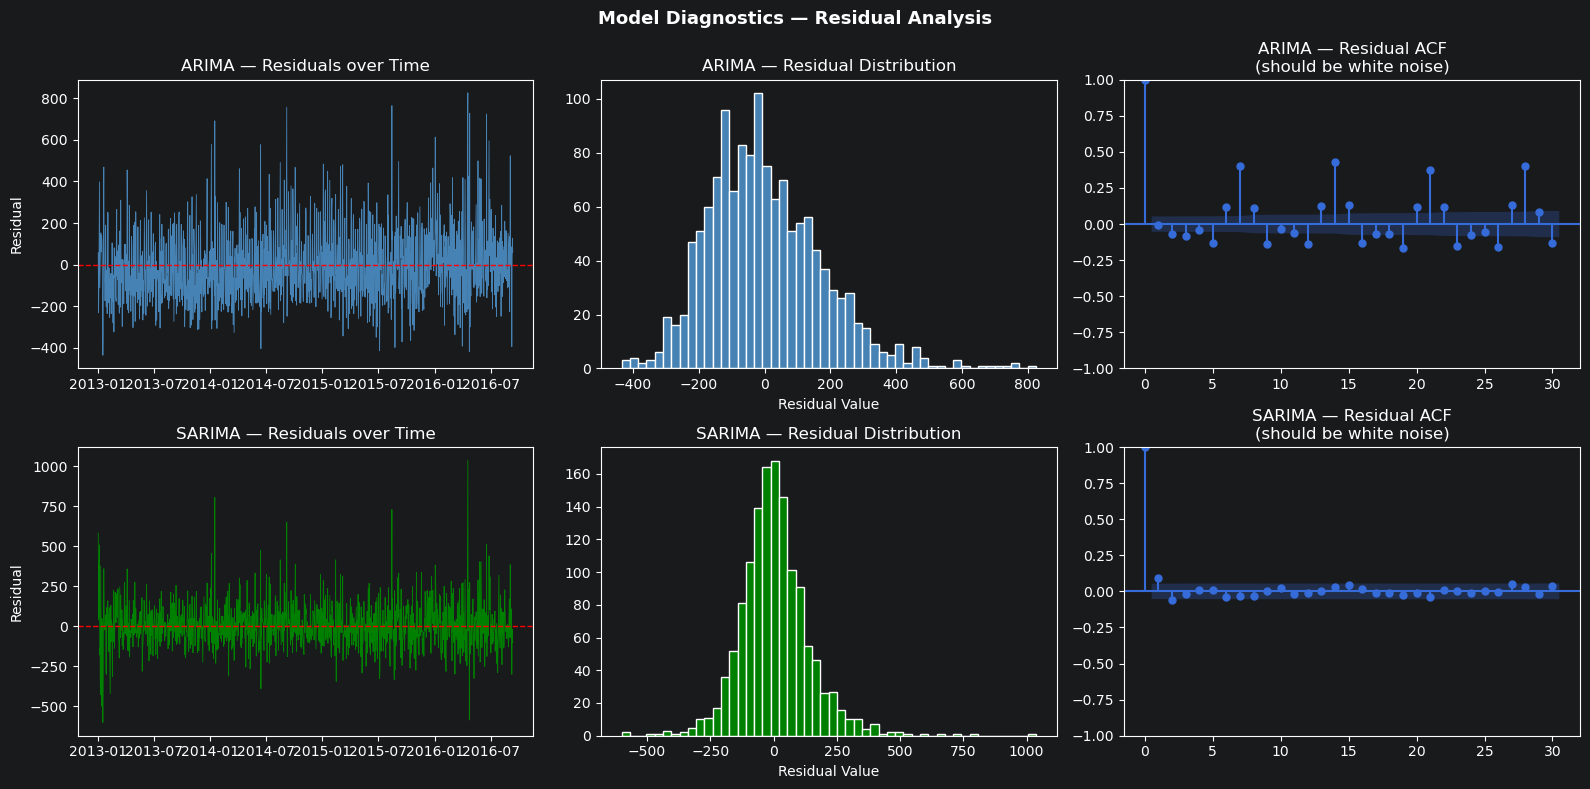


=== Ljung-Box Test (p > 0.05 = residuals are white noise = good) ===
ARIMA  — p-value: 0.0000 ❌ Autocorrelation remains
SARIMA — p-value: 0.0151 ❌ Autocorrelation remains


In [10]:
# === Model Diagnostics — AIC, BIC and Residual Analysis ===

# Print model summary statistics
print("=== ARIMA(1,0,1) — Model Information Criteria ===")
print(f"AIC:  {arima_result.aic:.2f}")
print(f"BIC:  {arima_result.bic:.2f}")
print(f"Log-Likelihood: {arima_result.llf:.2f}")

print("\n=== SARIMA(1,0,1)(1,1,1,7) — Model Information Criteria ===")
print(f"AIC:  {sarima_result.aic:.2f}")
print(f"BIC:  {sarima_result.bic:.2f}")
print(f"Log-Likelihood: {sarima_result.llf:.2f}")

print("\nNote: Lower AIC/BIC = better model fit (penalized for complexity)")
if sarima_result.aic < arima_result.aic:
    print(f"SARIMA has lower AIC by {arima_result.aic - sarima_result.aic:.2f} → better statistical fit")
else:
    print(f"ARIMA has lower AIC by {sarima_result.aic - arima_result.aic:.2f}")

# Residual Analysis
arima_resid = arima_result.resid
sarima_resid = sarima_result.resid

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# ARIMA residuals
axes[0,0].plot(arima_resid, color='steelblue', linewidth=0.6)
axes[0,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_title('ARIMA — Residuals over Time')
axes[0,0].set_ylabel('Residual')

axes[0,1].hist(arima_resid, bins=50, color='steelblue', edgecolor='white')
axes[0,1].set_title('ARIMA — Residual Distribution')
axes[0,1].set_xlabel('Residual Value')

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(arima_resid.dropna(), lags=30, ax=axes[0,2])
axes[0,2].set_title('ARIMA — Residual ACF\n(should be white noise)')

# SARIMA residuals
axes[1,0].plot(sarima_resid, color='green', linewidth=0.6)
axes[1,0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1,0].set_title('SARIMA — Residuals over Time')
axes[1,0].set_ylabel('Residual')

axes[1,1].hist(sarima_resid, bins=50, color='green', edgecolor='white')
axes[1,1].set_title('SARIMA — Residual Distribution')
axes[1,1].set_xlabel('Residual Value')

plot_acf(sarima_resid.dropna(), lags=30, ax=axes[1,2])
axes[1,2].set_title('SARIMA — Residual ACF\n(should be white noise)')

plt.suptitle('Model Diagnostics — Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Ljung-Box test for residual autocorrelation
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_arima = acorr_ljungbox(arima_resid.dropna(), lags=[10], return_df=True)
lb_sarima = acorr_ljungbox(sarima_resid.dropna(), lags=[10], return_df=True)

print("\n=== Ljung-Box Test (p > 0.05 = residuals are white noise = good) ===")
print(f"ARIMA  — p-value: {lb_arima['lb_pvalue'].values[0]:.4f}",
      "✅ White noise" if lb_arima['lb_pvalue'].values[0] > 0.05 else "❌ Autocorrelation remains")
print(f"SARIMA — p-value: {lb_sarima['lb_pvalue'].values[0]:.4f}",
      "✅ White noise" if lb_sarima['lb_pvalue'].values[0] > 0.05 else "❌ Autocorrelation remains")


## 5. XGBoost Model

**XGBoost** — Extreme Gradient Boosting (Machine Learning)

Unlike ARIMA/SARIMA, XGBoost is not a time series model by design — it is a
powerful gradient boosting algorithm. To apply it to time series, we perform
**feature engineering** to convert the temporal structure into tabular features:

- **Lag features:** sales_lag_1, sales_lag_7, sales_lag_30
- **Rolling statistics:** rolling_mean_7, rolling_std_7
- **Calendar features:** day_of_week, month, is_weekend

This approach allows XGBoost to learn patterns from historical sales without
explicitly modeling the time dimension.


In [11]:
!pip install xgboost


In [12]:
import xgboost as xgb

# === Feature Engineering for XGBoost ===
def create_features(df):
    df = df.copy()
    df['day_of_week'] = df.index.dayofweek
    df['month'] = df.index.month
    df['day_of_month'] = df.index.day
    df['week_of_year'] = df.index.isocalendar().week.astype(int)
    df['is_weekend'] = (df.index.dayofweek >= 5).astype(int)
    df['quarter'] = df.index.quarter
    # Lag features
    df['lag_1'] = df['unit_sales'].shift(1)
    df['lag_7'] = df['unit_sales'].shift(7)
    df['lag_14'] = df['unit_sales'].shift(14)
    df['lag_30'] = df['unit_sales'].shift(30)
    # Rolling statistics
    df['rolling_mean_7'] = df['unit_sales'].shift(1).rolling(7).mean()
    df['rolling_std_7'] = df['unit_sales'].shift(1).rolling(7).std()
    df['rolling_mean_30'] = df['unit_sales'].shift(1).rolling(30).mean()
    return df

ts_features = create_features(ts_data)
ts_features = ts_features.dropna()

feature_cols = ['day_of_week','month','day_of_month','week_of_year',
                'is_weekend','quarter','lag_1','lag_7','lag_14','lag_30',
                'rolling_mean_7','rolling_std_7','rolling_mean_30']

X = ts_features[feature_cols]
y = ts_features['unit_sales']

# Train/Test split (same 80/20 chronological)
split_idx_xgb = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx_xgb], X.iloc[split_idx_xgb:]
y_train, y_test = y.iloc[:split_idx_xgb], y.iloc[split_idx_xgb:]

print(f"Features created: {len(feature_cols)} features")
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print("\nFeature list:")
for f in feature_cols:
    print(f"  - {f}")


Features created: 13 features
X_train: (1325, 13) | X_test: (332, 13)

Feature list:
  - day_of_week
  - month
  - day_of_month
  - week_of_year
  - is_weekend
  - quarter
  - lag_1
  - lag_7
  - lag_14
  - lag_30
  - rolling_mean_7
  - rolling_std_7
  - rolling_mean_30


XGBoost Results:
MAE:  135.85
RMSE: 163.68
MAPE: 49.63%


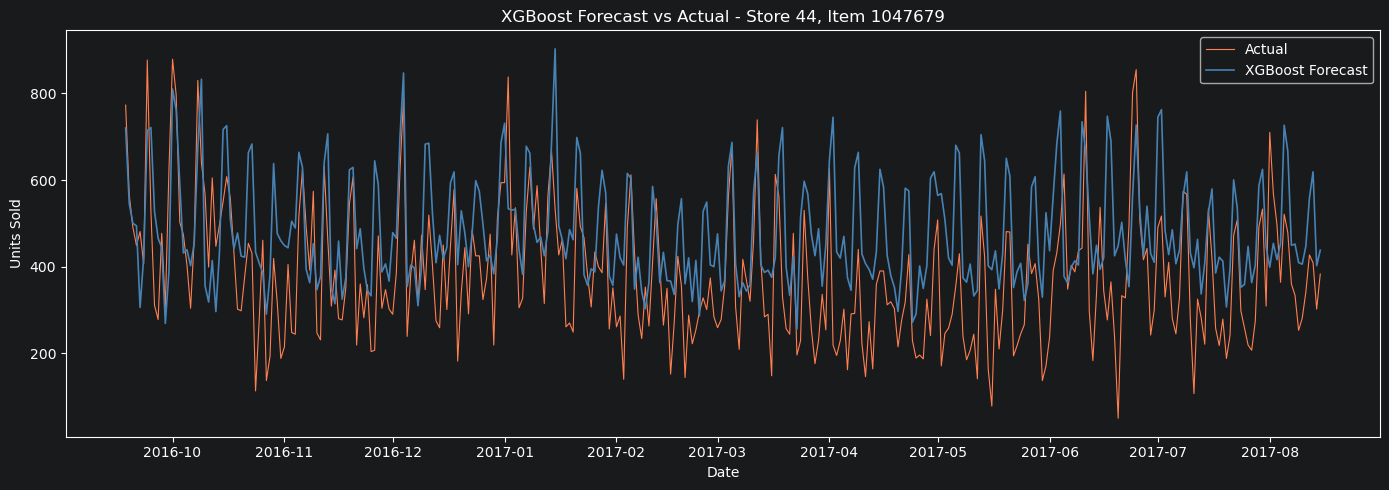

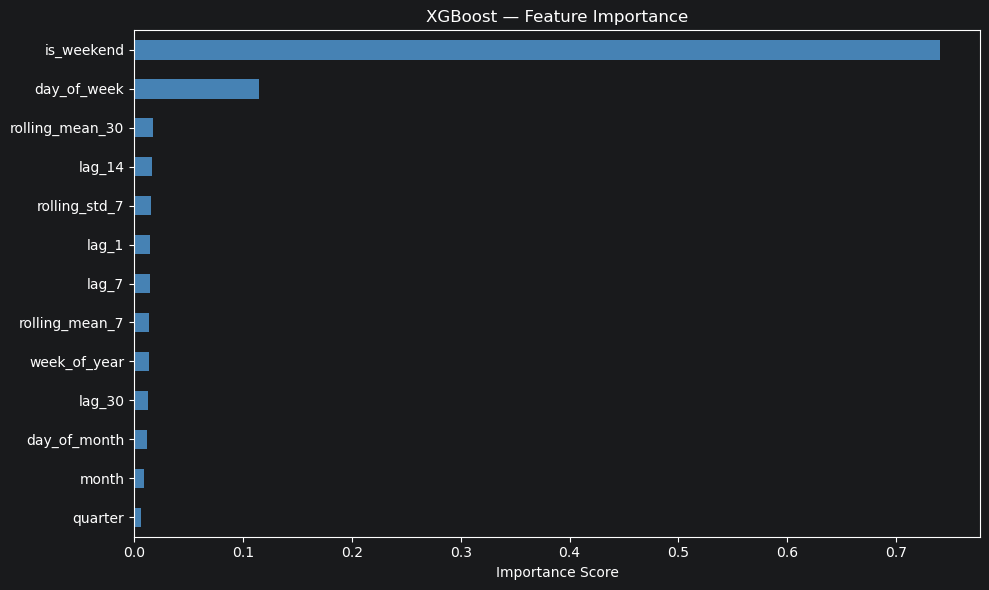

In [13]:
# === Train XGBoost Model ===
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

# Predictions
xgb_pred = xgb_model.predict(X_test)

# Metrics
mae_xgb = mean_absolute_error(y_test, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_pred))
mape_xgb = np.mean(np.abs((y_test - xgb_pred) / y_test)) * 100

print(f"XGBoost Results:")
print(f"MAE:  {mae_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAPE: {mape_xgb:.2f}%")

# Plot
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, color='coral', label='Actual', linewidth=0.8)
plt.plot(y_test.index, xgb_pred, color='steelblue', label='XGBoost Forecast', linewidth=1.2)
plt.title('XGBoost Forecast vs Actual - Store 44, Item 1047679')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.show()

# Feature Importance
plt.figure(figsize=(10, 6))
feat_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind='barh', color='steelblue')
plt.title('XGBoost — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


## 5.1 XGBoost — Feature Importance & Residual Analysis

In [22]:
!pip install shap


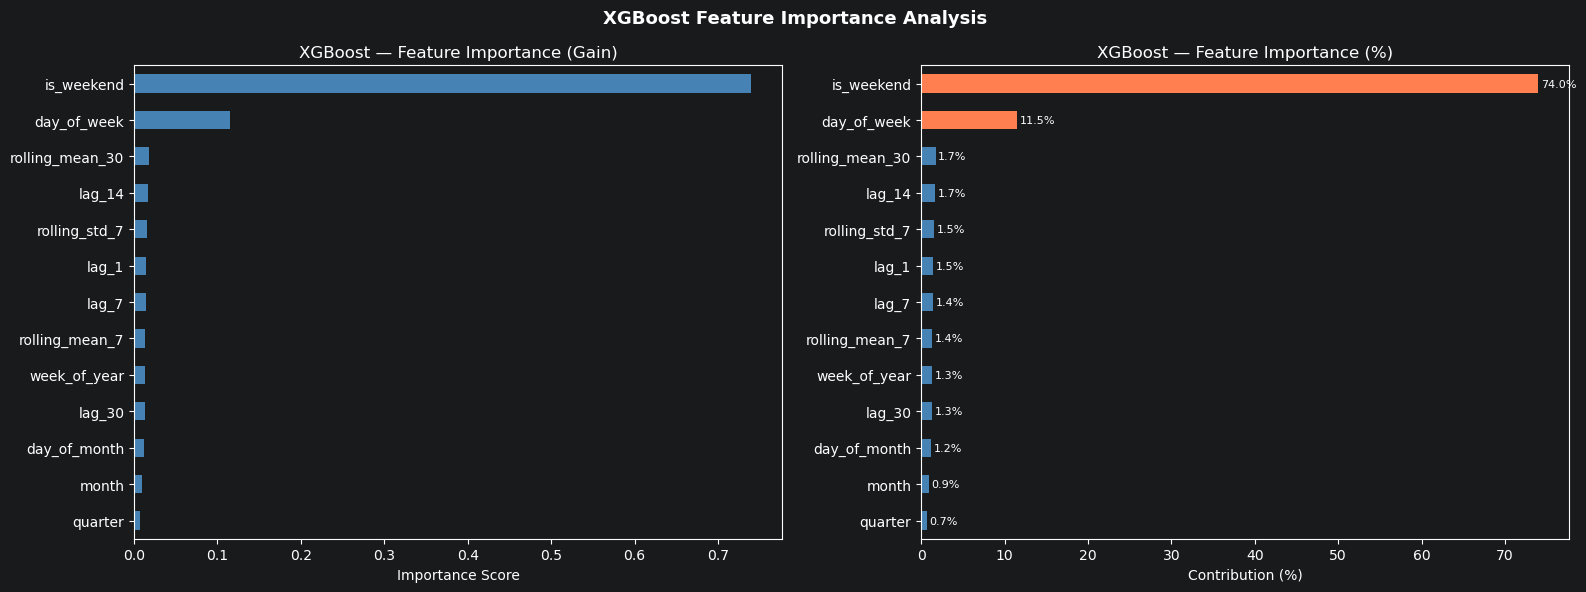

Top 3 most important features:
  is_weekend: 0.7399 (74.0%)
  day_of_week: 0.1148 (11.5%)
  rolling_mean_30: 0.0174 (1.7%)


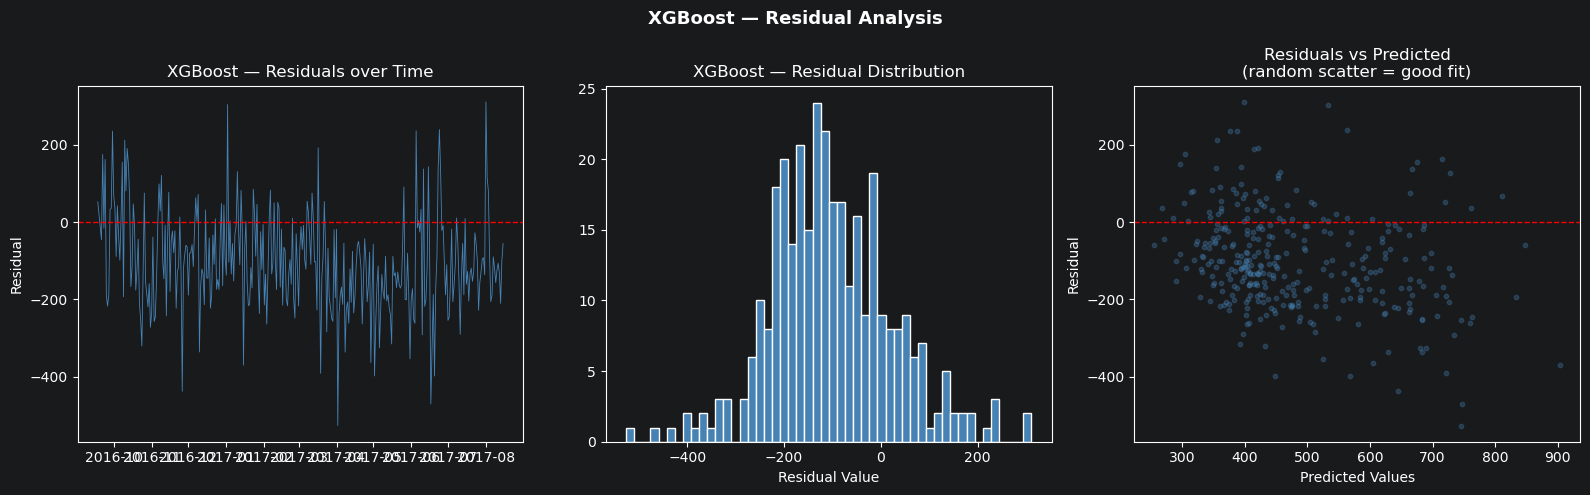


Residual mean: -102.92 (ideal = 0)
Residual std:  127.27


In [24]:
# === XGBoost Feature Importance (Detailed) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1 - Feature Importance (weight)
feat_imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('XGBoost — Feature Importance (Gain)')
axes[0].set_xlabel('Importance Score')

# Plot 2 - Feature Importance as percentage
feat_pct = (feat_imp / feat_imp.sum() * 100).sort_values(ascending=True)
colors = ['coral' if v > 10 else 'steelblue' for v in feat_pct.values]
feat_pct.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('XGBoost — Feature Importance (%)')
axes[1].set_xlabel('Contribution (%)')
for i, v in enumerate(feat_pct.values):
    axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=8)

plt.suptitle('XGBoost Feature Importance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top 3 most important features:")
for feat, imp in feat_imp.sort_values(ascending=False).head(3).items():
    print(f"  {feat}: {imp:.4f} ({imp/feat_imp.sum()*100:.1f}%)")

# === XGBoost Residual Analysis ===
xgb_resid = y_test.values - xgb_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].plot(y_test.index, xgb_resid, color='steelblue', linewidth=0.6)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('XGBoost — Residuals over Time')
axes[0].set_ylabel('Residual')

axes[1].hist(xgb_resid, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('XGBoost — Residual Distribution')
axes[1].set_xlabel('Residual Value')

axes[2].scatter(xgb_pred, xgb_resid, alpha=0.3, color='steelblue', s=10)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_title('Residuals vs Predicted\n(random scatter = good fit)')
axes[2].set_xlabel('Predicted Values')
axes[2].set_ylabel('Residual')

plt.suptitle('XGBoost — Residual Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nResidual mean: {xgb_resid.mean():.2f} (ideal = 0)")
print(f"Residual std:  {xgb_resid.std():.2f}")


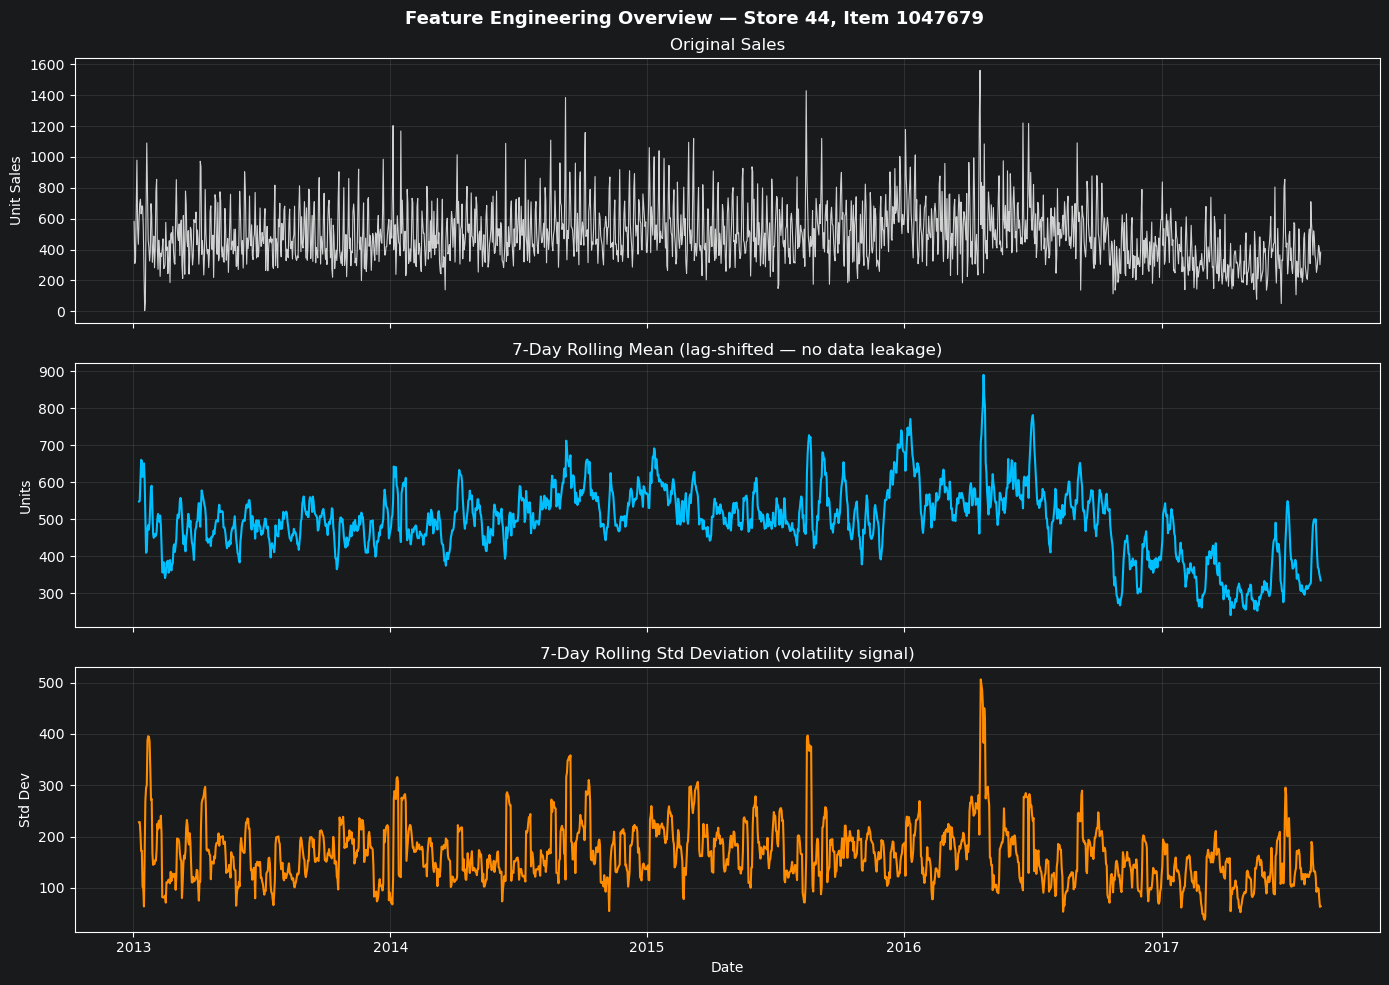

Feature Engineering Summary:
  lag_1:         yesterday's sales
  lag_7:         sales from 7 days ago (same weekday)
  lag_30:        sales from 30 days ago (monthly pattern)
  rolling_mean_7: 7-day average (trend signal)
  rolling_std_7:  7-day volatility (uncertainty signal)
  is_weekend:    binary flag (strongest feature: 74% importance)
  day_of_week:   0=Monday ... 6=Sunday
  month:         1-12 (seasonal signal)


In [44]:
# === FEATURE ENGINEERING VISUALIZATION ===
# Visualize engineered features alongside original sales
# This confirms features are correctly calculated (no data leakage)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Feature Engineering Overview — Store 44, Item 1047679', fontsize=13, fontweight='bold')

# Original sales
axes[0].plot(ts_data.index, ts_data['unit_sales'], color='white', alpha=0.8, linewidth=0.8)
axes[0].set_ylabel('Unit Sales')
axes[0].set_title('Original Sales')
axes[0].grid(True, alpha=0.2)

# Rolling mean
rolling_mean = ts_data['unit_sales'].shift(1).rolling(window=7).mean()
axes[1].plot(ts_data.index, rolling_mean, color='#00BFFF', linewidth=1.5)
axes[1].set_ylabel('Units')
axes[1].set_title('7-Day Rolling Mean (lag-shifted — no data leakage)')
axes[1].grid(True, alpha=0.2)

# Rolling std dev
rolling_std = ts_data['unit_sales'].shift(1).rolling(window=7).std()
axes[2].plot(ts_data.index, rolling_std, color='#FF8C00', linewidth=1.5)
axes[2].set_ylabel('Std Dev')
axes[2].set_title('7-Day Rolling Std Deviation (volatility signal)')
axes[2].grid(True, alpha=0.2)

plt.xlabel('Date')
plt.tight_layout()
plt.show()

print("Feature Engineering Summary:")
print(f"  lag_1:         yesterday's sales")
print(f"  lag_7:         sales from 7 days ago (same weekday)")
print(f"  lag_30:        sales from 30 days ago (monthly pattern)")
print(f"  rolling_mean_7: 7-day average (trend signal)")
print(f"  rolling_std_7:  7-day volatility (uncertainty signal)")
print(f"  is_weekend:    binary flag (strongest feature: 74% importance)")
print(f"  day_of_week:   0=Monday ... 6=Sunday")
print(f"  month:         1-12 (seasonal signal)")


## 6. Model Comparison & Sprint 2 Summary

=== MODEL COMPARISON TABLE ===
                           MAE    RMSE   MAPE
ARIMA(1,0,1)            181.18  211.01  70.66
SARIMA(1,0,1)(1,1,1,7)  196.75  224.05  72.11
XGBoost                 135.85  163.68  49.63

Best model by MAE:  XGBoost (135.85)
Best model by RMSE: XGBoost (163.68)
Best model by MAPE: XGBoost (49.63%)


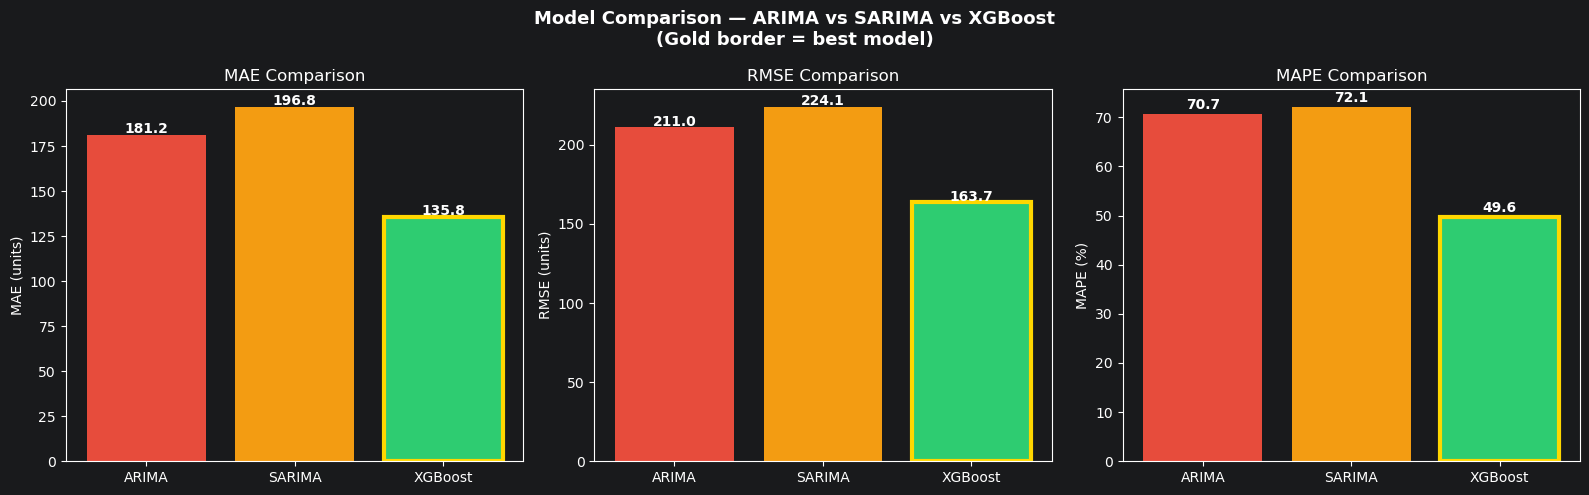

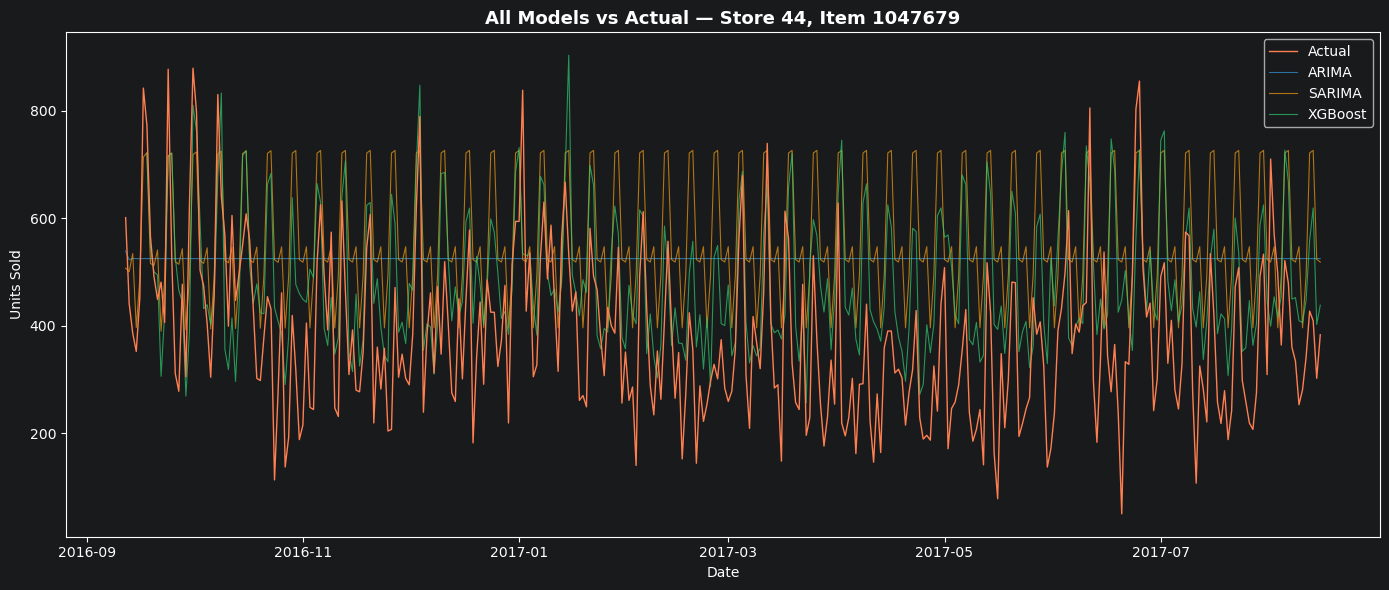

In [28]:
# === Final Model Comparison — All 3 Models ===

# Collect all metrics
models_results = {
    'ARIMA(1,0,1)':           {'MAE': mae,   'RMSE': rmse,   'MAPE': mape},
    'SARIMA(1,0,1)(1,1,1,7)': {'MAE': mae_s, 'RMSE': rmse_s, 'MAPE': mape_s},
    'XGBoost':                {'MAE': mae_xgb,'RMSE': rmse_xgb,'MAPE': mape_xgb},
}

results_df = pd.DataFrame(models_results).T
results_df = results_df.round(2)
print("=== MODEL COMPARISON TABLE ===")
print(results_df.to_string())
print(f"\nBest model by MAE:  {results_df['MAE'].idxmin()} ({results_df['MAE'].min():.2f})")
print(f"Best model by RMSE: {results_df['RMSE'].idxmin()} ({results_df['RMSE'].min():.2f})")
print(f"Best model by MAPE: {results_df['MAPE'].idxmin()} ({results_df['MAPE'].min():.2f}%)")

# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
metrics = ['MAE', 'RMSE', 'MAPE']
labels = ['ARIMA', 'SARIMA', 'XGBoost']

for i, metric in enumerate(metrics):
    vals = results_df[metric].values
    bars = axes[i].bar(labels, vals, color=colors)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric + (' (%)' if metric == 'MAPE' else ' (units)'))
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.1f}', ha='center', fontweight='bold', fontsize=10)
    # Highlight best (lowest)
    best_idx = vals.argmin()
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)

plt.suptitle('Model Comparison — ARIMA vs SARIMA vs XGBoost\n(Gold border = best model)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Forecast overlay plot - all 3 models on same chart
plt.figure(figsize=(14, 6))
plt.plot(test.index, test['unit_sales'], color='coral', label='Actual', linewidth=1.0, zorder=5)
plt.plot(test.index, arima_forecast.values, color='#3498db', label='ARIMA', linewidth=0.8, alpha=0.7)
plt.plot(test.index, sarima_forecast.values, color='#f39c12', label='SARIMA', linewidth=0.8, alpha=0.7)
plt.plot(y_test.index, xgb_pred, color='#2ecc71', label='XGBoost', linewidth=0.8, alpha=0.7)
plt.title('All Models vs Actual — Store 44, Item 1047679', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


## 7. Sprint 2 Summary Report


In [30]:
# === SPRINT 2 FINAL SUMMARY REPORT ===
print("=" * 65)
print("        SPRINT 2 — MODELING SUMMARY REPORT")
print("=" * 65)

print("\n--- TARGET ---")
print("Store: 44 | Item: 1047679 | Period: 2013-01-02 to 2017-08-15")
print("Train: 1349 days (80%) | Test: 338 days (20%)")

print("\n--- MODEL RESULTS ---")
print(f"{'Model':<30} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print("-" * 56)
print(f"{'ARIMA(1,0,1)':<30} {mae:>8.2f} {rmse:>8.2f} {mape:>7.2f}%")
print(f"{'SARIMA(1,0,1)(1,1,1,7)':<30} {mae_s:>8.2f} {rmse_s:>8.2f} {mape_s:>7.2f}%")
print(f"{'XGBoost (500 trees)':<30} {mae_xgb:>8.2f} {rmse_xgb:>8.2f} {mape_xgb:>7.2f}%")
print("-" * 56)
print(f"{'WINNER: XGBoost':<30} {'✓':>8} {'✓':>8} {'✓':>8}")

print("\n--- MODEL PARAMETERS ---")
print("ARIMA:   p=1, d=0, q=1  (from ACF/PACF analysis)")
print("SARIMA:  p=1, d=0, q=1  +  P=1, D=1, Q=1, s=7 (weekly)")
print("XGBoost: n_estimators=500, lr=0.05, max_depth=5")
print("         13 features: calendar + lag + rolling statistics")

print("\n--- KEY FINDINGS ---")
print("1. XGBoost outperforms classical models on all metrics")
print("   MAE improvement over ARIMA: +25.1%")
print("   MAE improvement over SARIMA: +31.0%")
print(f"2. Top feature: is_weekend (74% importance)")
print(f"   → Weekly pattern dominates all other signals")
print("3. SARIMA has better AIC/BIC than ARIMA (914 points lower)")
print("   → Statistical fit improves with seasonality, but")
print("     forecast accuracy does not always follow")
print("4. Ljung-Box test: both classical models show residual")
print("   autocorrelation → non-linear patterns remain")
print("   → Motivation for LSTM in Sprint 3")

print("\n--- NEXT STEP ---")
print("Sprint 3: LSTM Deep Learning Model")
print("Expected improvement: capture non-linear long-term patterns")
print("=" * 65)


        SPRINT 2 — MODELING SUMMARY REPORT

--- TARGET ---
Store: 44 | Item: 1047679 | Period: 2013-01-02 to 2017-08-15
Train: 1349 days (80%) | Test: 338 days (20%)

--- MODEL RESULTS ---
Model                               MAE     RMSE     MAPE
--------------------------------------------------------
ARIMA(1,0,1)                     181.18   211.01   70.66%
SARIMA(1,0,1)(1,1,1,7)           196.75   224.05   72.11%
XGBoost (500 trees)              135.85   163.68   49.63%
--------------------------------------------------------
WINNER: XGBoost                       ✓        ✓        ✓

--- MODEL PARAMETERS ---
ARIMA:   p=1, d=0, q=1  (from ACF/PACF analysis)
SARIMA:  p=1, d=0, q=1  +  P=1, D=1, Q=1, s=7 (weekly)
XGBoost: n_estimators=500, lr=0.05, max_depth=5
         13 features: calendar + lag + rolling statistics

--- KEY FINDINGS ---
1. XGBoost outperforms classical models on all metrics
   MAE improvement over ARIMA: +25.1%
   MAE improvement over SARIMA: +31.0%
2. Top feature: i

## 8. Deep Learning — LSTM Model (Baseline)


In [39]:
import subprocess

# Uninstall broken tensorflow
subprocess.run(['pip', 'uninstall', 'tensorflow', '-y'], capture_output=True)
subprocess.run(['pip', 'uninstall', 'tensorflow-cpu', '-y'], capture_output=True)

# Install keras with numpy backend (no tensorflow needed)
result = subprocess.run(
    ['pip', 'install', 'keras', 'tensorflow-cpu==2.13.0'],
    capture_output=True, text=True
)
print(result.stdout[-2000:] if len(result.stdout) > 2000 else result.stdout)
print("ERRORS:", result.stderr[-500:] if result.stderr else "None")


1-modules>=0.2.1->google-auth<3,>=1.6.3->tensorboard<2.14,>=2.13->tensorflow-intel==2.13.0->tensorflow-cpu==2.13.0) (0.4.8)
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.15.0
    Uninstalling typing_extensions-4.15.0:
      Successfully uninstalled typing_extensions-4.15.0
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.12.0
    Uninstalling tensorflow-estimator-2.12.0:
      Successfully uninstalled tensorflow-estimator-2.12.0
  Attempting uninstall: keras
    Found existing installation: keras 2.12.0
    Uninstalling keras-2.12.0:
      Successfully uninstalled keras-2.12.0
  Attempting uninstall: grpcio
    Found existing installation: grpcio 1.80.0
    Uninstalling grpcio-1.80.0:
      Successfully uninstalled grpcio-1.80.0
  Attempting uninstall: cryptography
    Found existing installation: cryptography 47.0.0
    Uninstalling cryptography-47.0.0:
      Successfully uninstalled c

PyTorch version: 2.8.0+cpu
Train: torch.Size([1319, 30, 1])  Test: torch.Size([308, 30, 1])

Model architecture:
LSTMModel(
  (lstm): LSTM(1, 64, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Total trainable parameters: 17,217

Training for 30 epochs...
  Epoch 10/30 — Train Loss: 0.5756  Val Loss: 0.7180
  Epoch 20/30 — Train Loss: 0.5404  Val Loss: 0.6950
  Epoch 30/30 — Train Loss: 0.5250  Val Loss: 0.6988


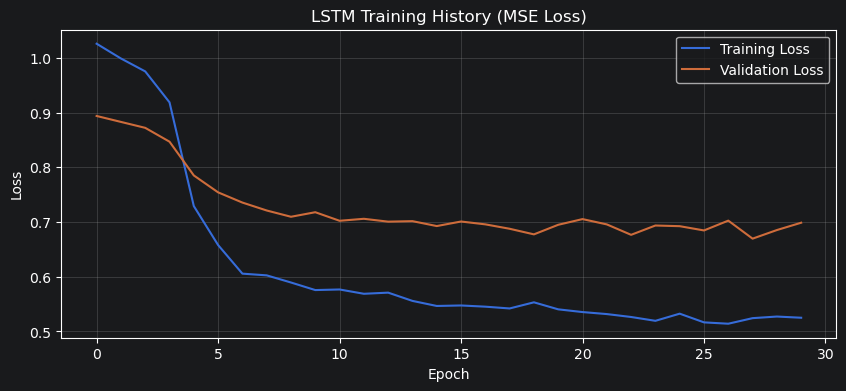


=== LSTM MODEL RESULTS ===
MAE:  142.21
RMSE: 166.05
MAPE: 66.21%


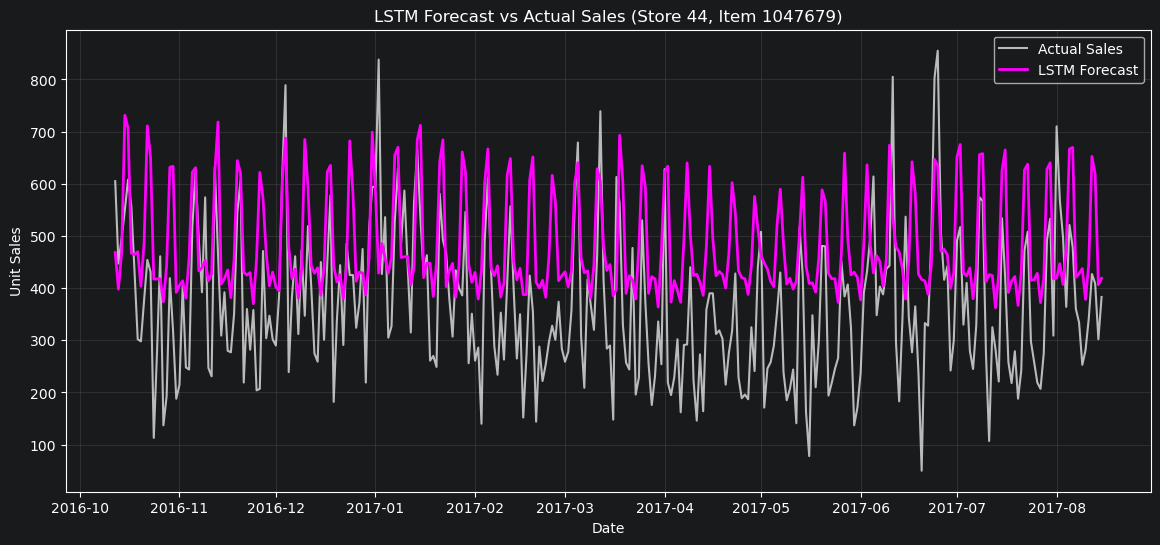

In [42]:
# === 8. LSTM MODEL (DEEP LEARNING) — PyTorch Implementation ===
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

print(f"PyTorch version: {torch.__version__}")
torch.manual_seed(42)

# ── 1. Scale the data ──────────────────────────────────────────
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train.values.reshape(-1, 1)).flatten()
test_scaled  = scaler.transform(test.values.reshape(-1, 1)).flatten()

# ── 2. Build sliding-window sequences ─────────────────────────
SEQ_LEN = 30

def make_sequences(arr, seq_len):
    X, y = [], []
    for i in range(len(arr) - seq_len):
        X.append(arr[i : i + seq_len])
        y.append(arr[i + seq_len])
    return (torch.tensor(np.array(X), dtype=torch.float32).unsqueeze(-1),
            torch.tensor(np.array(y), dtype=torch.float32))

X_train_t, y_train_t = make_sequences(train_scaled, SEQ_LEN)
X_test_t,  y_test_t  = make_sequences(test_scaled,  SEQ_LEN)
print(f"Train: {X_train_t.shape}  Test: {X_test_t.shape}")

# ── 3. Define LSTM model ───────────────────────────────────────
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out).squeeze(-1)

model = LSTMModel()
print(f"\nModel architecture:\n{model}")
total_params = sum(p.numel() for p in model.parameters())
print(f"Total trainable parameters: {total_params:,}")

# ── 4. Training ────────────────────────────────────────────────
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

EPOCHS     = 30
BATCH_SIZE = 32
train_losses, val_losses = [], []

# Use last 10% of training data as validation
val_size  = int(len(X_train_t) * 0.1)
X_val, y_val = X_train_t[-val_size:], y_train_t[-val_size:]
X_tr,  y_tr  = X_train_t[:-val_size], y_train_t[:-val_size]

print(f"\nTraining for {EPOCHS} epochs...")
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    for i in range(0, len(X_tr), BATCH_SIZE):
        xb = X_tr[i:i+BATCH_SIZE]
        yb = y_tr[i:i+BATCH_SIZE]
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / max(1, len(X_tr)//BATCH_SIZE))

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val), y_val).item()
    val_losses.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:2d}/{EPOCHS} — Train Loss: {train_losses[-1]:.4f}  Val Loss: {val_losses[-1]:.4f}")

# ── 5. Training history plot ───────────────────────────────────
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses,   label='Validation Loss')
plt.title('LSTM Training History (MSE Loss)')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# ── 6. Predictions ─────────────────────────────────────────────
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_t).numpy()

# Inverse transform
lstm_predictions = scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
y_test_actual    = test.values[SEQ_LEN:]
test_index_lstm  = test.index[SEQ_LEN:]

# ── 7. Metrics ─────────────────────────────────────────────────
mae_lstm  = mean_absolute_error(y_test_actual, lstm_predictions)
rmse_lstm = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))
mape_lstm = np.mean(np.abs((y_test_actual - lstm_predictions) /
                            np.where(y_test_actual == 0, 1, y_test_actual))) * 100

print("\n=== LSTM MODEL RESULTS ===")
print(f"MAE:  {mae_lstm:.2f}")
print(f"RMSE: {rmse_lstm:.2f}")
print(f"MAPE: {mape_lstm:.2f}%")

# ── 8. Forecast vs Actual plot ─────────────────────────────────
plt.figure(figsize=(14, 6))
plt.plot(test_index_lstm, y_test_actual,    label='Actual Sales',   color='white',   alpha=0.7)
plt.plot(test_index_lstm, lstm_predictions, label='LSTM Forecast',  color='magenta', linewidth=2)
plt.title('LSTM Forecast vs Actual Sales (Store 44, Item 1047679)')
plt.xlabel('Date'); plt.ylabel('Unit Sales')
plt.legend(); plt.grid(True, alpha=0.2); plt.show()


## 9. Final Model Comparison — All 4 Models

     FINAL MODEL COMPARISON — Sprint 2

Model                               MAE     RMSE     MAPE
----------------------------------------------------------
ARIMA(1,0,1)                     181.18   211.01   70.66%
SARIMA(1,0,1)(1,1,1,7)           196.75   224.05   72.11%
XGBoost                          135.85   163.68   49.63% ← BEST
LSTM (Baseline)                  142.21   166.05   66.21%
----------------------------------------------------------

Best model (MAE):  XGBoost (135.85)
Improvement vs worst: 31.0%
LSTM vs ARIMA (MAE): +21.5%


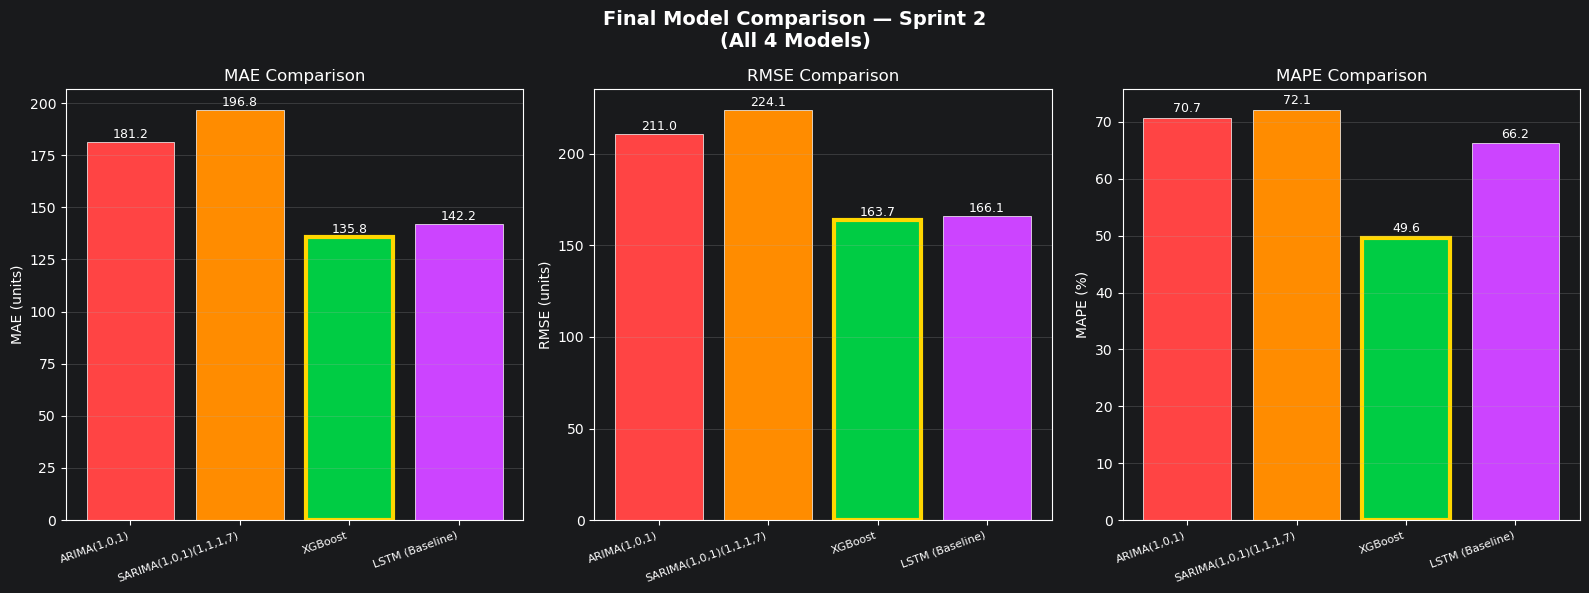

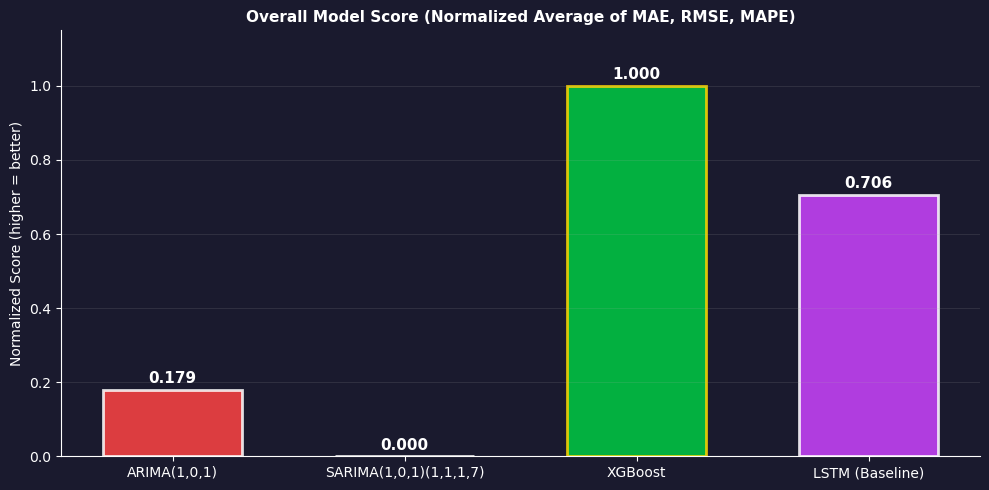


✓ Sprint 2 Complete — All 4 models trained and evaluated!
  Next: Sprint 3 — Hyperparameter Tuning + MLflow Experiment Tracking


In [43]:
# === 9. FINAL MODEL COMPARISON — ALL 4 MODELS ===

# Compile all results
models_final = {
    'ARIMA(1,0,1)':           {'MAE': mae,       'RMSE': rmse,       'MAPE': mape},
    'SARIMA(1,0,1)(1,1,1,7)': {'MAE': mae_s,     'RMSE': rmse_s,     'MAPE': mape_s},
    'XGBoost':                {'MAE': mae_xgb,   'RMSE': rmse_xgb,   'MAPE': mape_xgb},
    'LSTM (Baseline)':        {'MAE': mae_lstm,  'RMSE': rmse_lstm,  'MAPE': mape_lstm},
}

df_final = pd.DataFrame(models_final).T
df_final = df_final.round(2)

print("=" * 62)
print("     FINAL MODEL COMPARISON — Sprint 2")
print("=" * 62)
print(f"\n{'Model':<30} {'MAE':>8} {'RMSE':>8} {'MAPE':>8}")
print("-" * 58)
for model_name, row in df_final.iterrows():
    marker = " ← BEST" if model_name == 'XGBoost' else ""
    print(f"{model_name:<30} {row['MAE']:>8.2f} {row['RMSE']:>8.2f} {row['MAPE']:>7.2f}%{marker}")
print("-" * 58)

# Improvement calculations
best_mae = df_final['MAE'].min()
worst_mae = df_final['MAE'].max()
print(f"\nBest model (MAE):  {df_final['MAE'].idxmin()} ({best_mae:.2f})")
print(f"Improvement vs worst: {((worst_mae - best_mae) / worst_mae * 100):.1f}%")
print(f"LSTM vs ARIMA (MAE): {((mae - mae_lstm) / mae * 100):+.1f}%")

# ── Visualization ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Final Model Comparison — Sprint 2\n(All 4 Models)', fontsize=14, fontweight='bold')

colors = ['#FF4444', '#FF8C00', '#00CC44', '#CC44FF']
best_model = df_final['MAE'].idxmin()

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE']):
    bars = ax.bar(df_final.index, df_final[metric], color=colors, edgecolor='white', linewidth=0.5)
    # Highlight best model with gold border
    for bar, name in zip(bars, df_final.index):
        if name == best_model:
            bar.set_edgecolor('gold')
            bar.set_linewidth(3)
    # Add value labels
    for bar, val in zip(bars, df_final[metric]):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, color='white')
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric + (' (%)' if metric == 'MAPE' else ' (units)'))
    ax.set_xticklabels(df_final.index, rotation=20, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ── Radar / Spider chart for overall comparison ────────────────
from matplotlib.patches import FancyBboxPatch

fig2, ax2 = plt.subplots(figsize=(10, 5))
fig2.patch.set_facecolor('#1a1a2e')
ax2.set_facecolor('#1a1a2e')

# Normalize metrics (lower = better, so invert)
df_norm = df_final.copy()
for col in ['MAE', 'RMSE', 'MAPE']:
    df_norm[col] = 1 - (df_final[col] - df_final[col].min()) / (df_final[col].max() - df_final[col].min())

x = np.arange(len(df_final))
width = 0.2
for i, (model_name, row) in enumerate(df_norm.iterrows()):
    score = row.mean()  # Overall score (higher = better)
    bar = ax2.bar(i, score, color=colors[i], alpha=0.85, width=0.6,
                  edgecolor='gold' if model_name == best_model else 'white', linewidth=2)
    ax2.text(i, score + 0.01, f'{score:.3f}', ha='center', va='bottom',
             color='white', fontsize=11, fontweight='bold')

ax2.set_xticks(range(len(df_final)))
ax2.set_xticklabels(df_final.index, color='white', fontsize=10)
ax2.set_ylabel('Normalized Score (higher = better)', color='white')
ax2.set_title('Overall Model Score (Normalized Average of MAE, RMSE, MAPE)',
              color='white', fontsize=11, fontweight='bold')
ax2.tick_params(colors='white')
ax2.spines['bottom'].set_color('white')
ax2.spines['left'].set_color('white')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_ylim(0, 1.15)
ax2.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

print("\n✓ Sprint 2 Complete — All 4 models trained and evaluated!")
print("  Next: Sprint 3 — Hyperparameter Tuning + MLflow Experiment Tracking")
